# Bloque 3 — Experimentos

Reconstruye `coins` (no usada en entrenamiento) limpia y con ruido gaussiano σ = 20/255 (una sola realización, RNG 44) para T0 ∈ {2, 4, 8}. Métricas contra la imagen limpia: MSE, PSNR (data_range = 1), coeficientes activos medios y tiempo.

Implementación: `src/evaluacion.py`. Productos: `resultados.csv`, `reconstrucciones.npz`, `evaluacion_meta.json`, `figuras/`. Documentación: `nota_resultados.md`.

In [1]:
# Localiza la raíz del repositorio (local o Kaggle) y la añade a sys.path.
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/SarahVasquezM/ksvd-image-denoising.git"
REPO_REF = os.environ.get("KSVD_REPO_REF", "codex/auditoria-final")

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "modelo.py").exists():
            return p
    if Path("/kaggle/working").exists():          # Kaggle: clonar el repositorio
        dest = Path("/kaggle/working/ksvd-image-denoising")
        if not dest.exists():
            subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_REF,
                            REPO_URL, str(dest)], check=True)
        return dest
    raise FileNotFoundError("No se encontró la raíz del repositorio")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
import warnings
# Mostrar advertencias sin rutas absolutas de la máquina (no se suprime ninguna).
warnings.formatwarning = lambda msg, cat, filename, lineno, line=None: (
    f"{cat.__name__} ({Path(filename).name}:{lineno}): {msg}\n")
from threadpoolctl import threadpool_limits
from src.pipeline import DEFAULT_THREADS, paths
threadpool_limits(limits=DEFAULT_THREADS)     # evita sobresuscripción BLAS con matrices pequeñas
P = paths(ROOT)
print("Raíz del repositorio:", ROOT.name)

Raíz del repositorio: ksvd-auditoria-final


## 1. Ejecutar experimentos (incluye las comprobaciones previas de métricas)

In [2]:
import json, pandas as pd
from src.pipeline import run_block3
df = run_block3(ROOT)
meta = json.loads((P["eval_dir"] / "evaluacion_meta.json").read_text(encoding="utf-8"))
print(json.dumps(meta["metric_checks"], indent=2))
print("σ empírica del ruido:", meta["noise_empirical_std"], " (nominal", 20/255, ")")
df

{
  "self_mse": 0.0,
  "self_psnr": Infinity,
  "const_0.1_mse": 0.01,
  "const_0.1_psnr": 20.0
}
σ empírica del ruido: 0.07860591954907652  (nominal 0.0784313725490196 )


,case_id,input_kind,method,sigma,condition,T0,mse,psnr_db,mean_active_coefs,max_active_coefs,reconstruction_time_s,coding_time_s,n_patches,n_atoms,max_nonzero,mean_nonzero,reconstruction_s,noise_seed
0,noisy_baseline,noisy,identity,0.078431,ruidosa_sin_procesar,0,0.006179,22.090880,NaN,NaN,NaN,NaN,NaN,128,0,NaN,NaN,44
1,clean_t2,clean,ksvd,0.078431,limpia,2,0.002132,26.712990,2.0,2.0,0.052232,0.042158,961.0,128,2,2.0,0.052232,44
2,clean_t4,clean,ksvd,0.078431,limpia,4,0.001264,28.982603,4.0,4.0,0.088511,0.080153,961.0,128,4,4.0,0.088511,44
3,clean_t8,clean,ksvd,0.078431,limpia,8,0.000719,31.430905,8.0,8.0,0.179354,0.163873,961.0,128,8,8.0,0.179354,44
4,noisy_t2,noisy,ksvd,0.078431,ruidosa,2,0.002784,25.553827,2.0,2.0,0.051862,0.043872,961.0,128,2,2.0,0.051862,44
5,noisy_t4,noisy,ksvd,0.078431,ruidosa,4,0.002442,26.121743,4.0,4.0,0.093958,0.082747,961.0,128,4,4.0,0.093958,44
6,noisy_t8,noisy,ksvd,0.078431,ruidosa,8,0.002730,25.638454,8.0,8.0,0.168103,0.160086,961.0,128,8,8.0,0.168103,44


## 2. Lectura de resultados (calculada, no escrita a mano)

In [3]:
base = df[df.condition == "ruidosa_sin_procesar"].iloc[0]
for cond in ("limpia", "ruidosa"):
    sub = df[df.condition == cond].sort_values("T0")
    best = sub.loc[sub.psnr_db.idxmax()]
    print(f"{cond:8s}: PSNR por T0 =", dict(zip(sub.T0, sub.psnr_db.round(3))), f"-> mejor T0={int(best.T0)}")
noisy = df[df.condition == "ruidosa"]
print(f"Ruidosa sin procesar: {base.psnr_db:.3f} dB; ganancia máx: {noisy.psnr_db.max() - base.psnr_db:.3f} dB")

limpia  : PSNR por T0 = {2: 26.713, 4: 28.983, 8: 31.431} -> mejor T0=8
ruidosa : PSNR por T0 = {2: 25.554, 4: 26.122, 8: 25.638} -> mejor T0=4
Ruidosa sin procesar: 22.091 dB; ganancia máx: 4.031 dB


## 3. Control: diccionario inicial `D_init` frente al diccionario aprendido

Análisis complementario (no forma parte de `resultados.csv`): misma imagen, mismo ruido y mismos T0, cambiando sólo el diccionario. Mide cuánto aporta el aprendizaje K-SVD frente a parches elegidos al azar.

In [4]:
import numpy as np, warnings
from src.evaluacion import reconstruct_image, psnr, make_noisy
from src.modelo import load_model
from src.preprocesamiento import load_dataset, load_config
cfg = load_config(P["config"]); m = load_model(P["modelo"]); test = load_dataset(P["datos"])["test_image"]
noisy, _ = make_noisy(test, cfg["sigma"], cfg["seeds"]["noise"])
rows = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="OMP terminó", category=RuntimeWarning)  # sólo parada temprana
    for name in ("D_init", "D"):
        for T0 in cfg["eval_sparsities"]:
            rows.append({"diccionario": name, "T0": T0,
                         "psnr_limpia": psnr(test, reconstruct_image(test, m[name], T0)["image"]),
                         "psnr_ruidosa": psnr(test, reconstruct_image(noisy, m[name], T0)["image"])})
ctrl = pd.DataFrame(rows).pivot(index="T0", columns="diccionario")
ctrl["ganancia_limpia_dB"] = ctrl[("psnr_limpia", "D")] - ctrl[("psnr_limpia", "D_init")]
ctrl["ganancia_ruidosa_dB"] = ctrl[("psnr_ruidosa", "D")] - ctrl[("psnr_ruidosa", "D_init")]
ctrl.round(3)

psnr_limpia         psnr_ruidosa         ganancia_limpia_dB  \
diccionario           D  D_init            D  D_init                      
T0                                                                        
2                26.713  26.355       25.554  25.338              0.358   
4                28.983  28.386       26.122  25.925              0.597   
8                31.431  30.829       25.638  25.586              0.602   

            ganancia_ruidosa_dB  
diccionario                      
T0                               
2                         0.216  
4                         0.196  
8                         0.052

## 4. Figuras

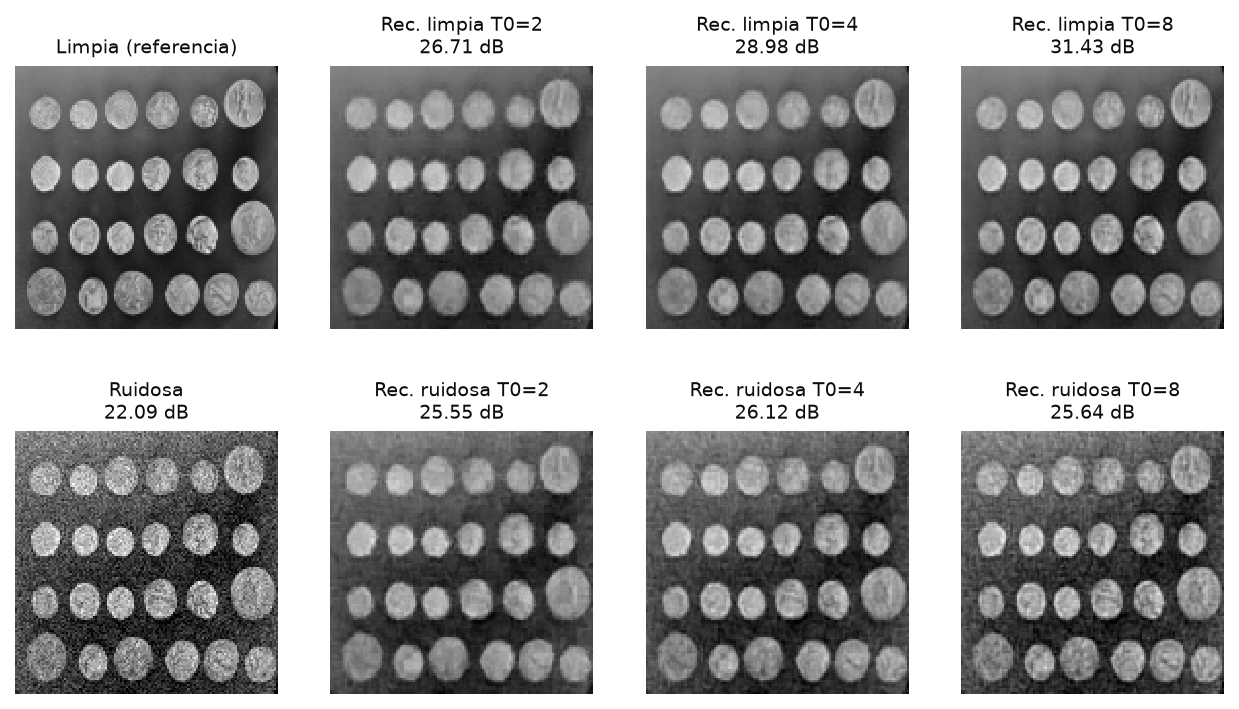

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "03_evaluacion/figuras/reconstrucciones.png")))

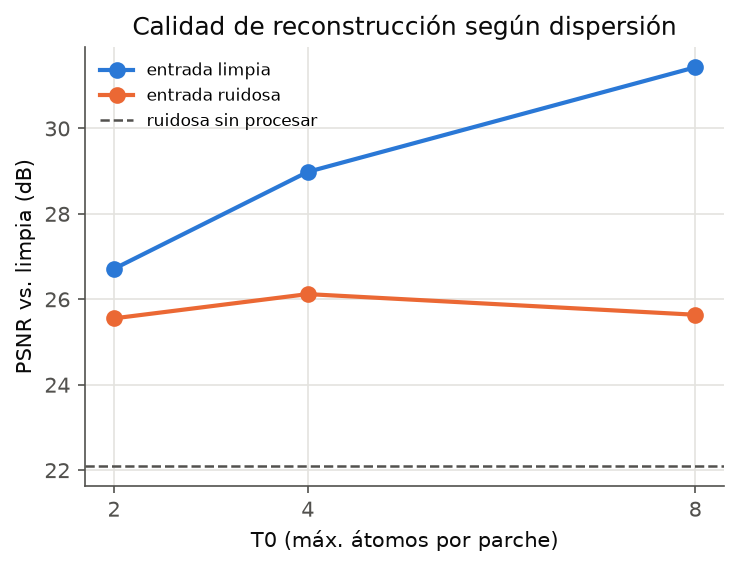

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "03_evaluacion/figuras/psnr_vs_t0.png")))

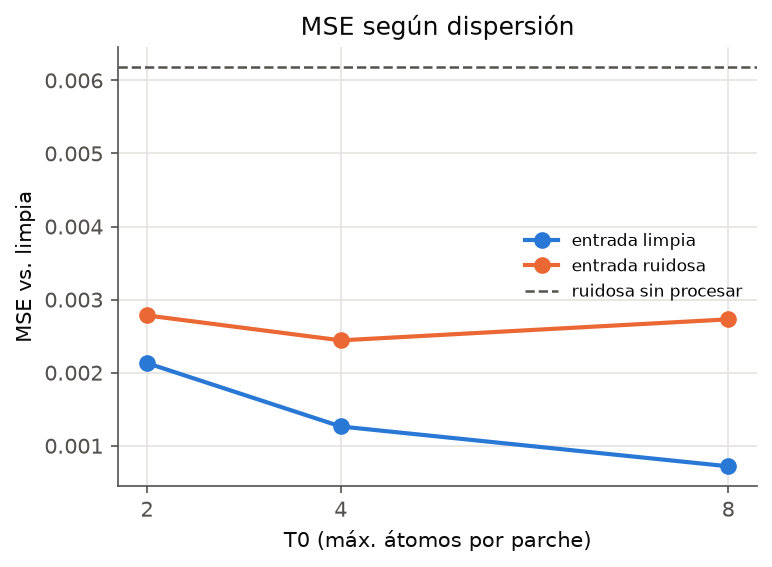

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "03_evaluacion/figuras/mse_vs_t0.png")))

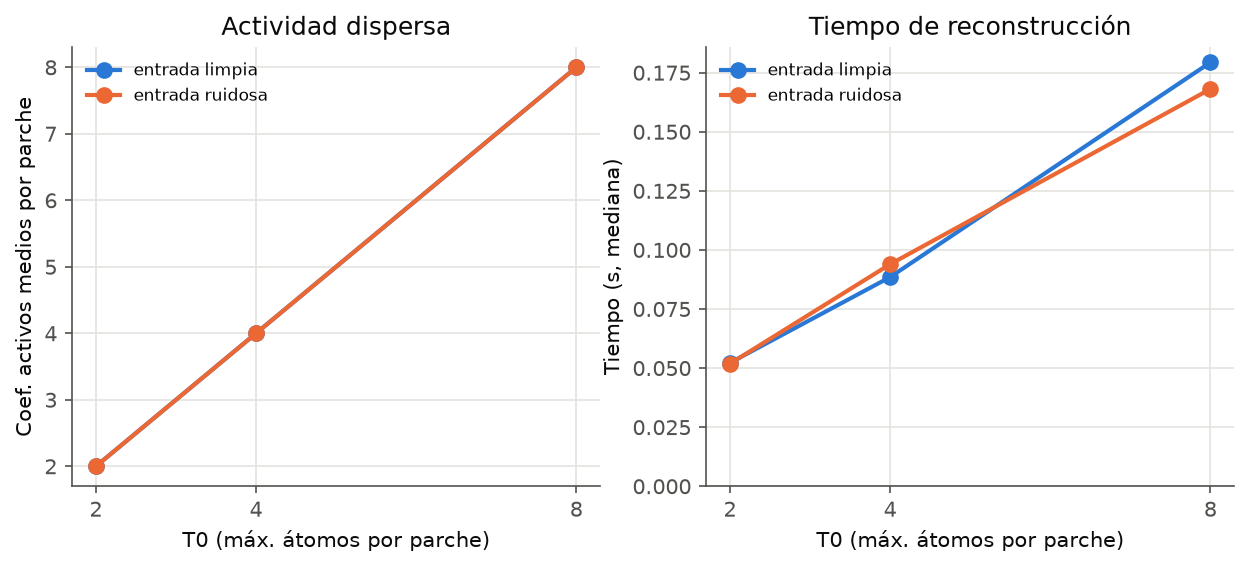

In [8]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "03_evaluacion/figuras/actividad_tiempo.png")))

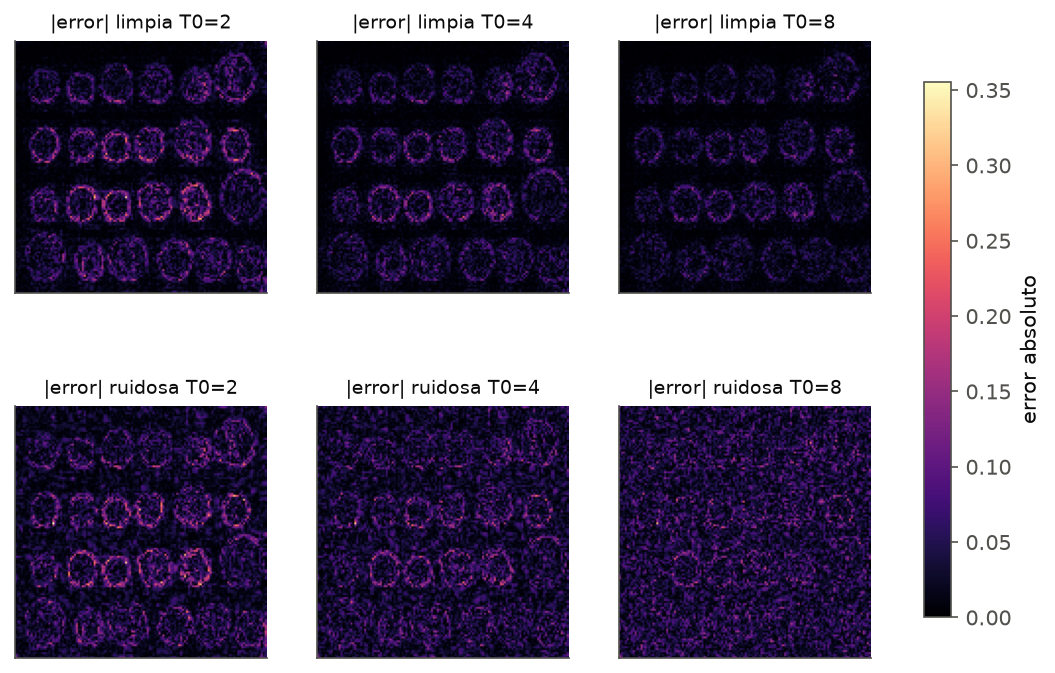

In [9]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "03_evaluacion/figuras/mapas_error.png")))